## Cityscapes数据集语义分割练习 — SegFormer

- 下载数据集：https://www.kaggle.com/datasets/xiaose/cityscapes
- 依赖：`segmentation_models_pytorch`（用于加载 MiT 预训练骨干网络）

In [1]:
# 安装额外依赖（如已安装可跳过）
!pip install segmentation_models_pytorch albumentations torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [2]:
import os
import cv2
import gc
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from typing import List, Optional, Union, Callable

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchmetrics
import albumentations as A
from albumentations.pytorch import ToTensorV2
from segmentation_models_pytorch.encoders import get_encoder
from torchmetrics.segmentation import DiceScore

In [3]:
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cuda')

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print(torch.version.cuda)
print(torch.__version__)

True
Tesla T4
12.8
2.10.0+cu128


### 加载数据

In [5]:
class CityscapesDataset(Dataset):
    """Cityscapes 语义分割数据集"""
    def __init__(self, image_dir, mask_dir, transforms=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_list = []
        self.transforms = transforms

        for city in os.listdir(self.image_dir):
            city_dir = os.path.join(self.image_dir, city)
            for f in os.listdir(city_dir):
                if f.endswith("_leftImg8bit.png"):
                    self.image_list.append(os.path.join(city, f))

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        rel_path = self.image_list[idx]
        city = rel_path.split("/")[0]
        image_name = rel_path.split("/")[1]

        image_path = os.path.join(self.image_dir, city, image_name)
        mask_path = os.path.join(
            self.mask_dir,
            city,
            image_name.replace("_leftImg8bit.png", "_gtFine_labelTrainIds.png"),
        )

        with Image.open(image_path) as img:
            image=np.array(img.convert("RGB"))
        with Image.open(mask_path) as m:
            mask=np.array(m,dtype=np.uint8)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(mask):
            mask = torch.from_numpy(mask)
        mask = mask.long()
        return image, mask


def SegmentationTransform(mode="train", image_height=512, image_width=512):
    """训练/验证数据增强与归一化"""
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    if mode == "train":
        transform = A.Compose([
            A.HorizontalFlip(p=0.5),
                A.Blur(),
                A.Sharpen(),
                A.RandomCrop(224, 224),
                A.HorizontalFlip(p=0.5),
                A.Rotate(limit=45, p=0.8),
                A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
                # A.RGBShift(),
                A.CoarseDropout(
                    num_holes_range=(1, 16),
                    hole_height_range=(8, 40),
                    hole_width_range=(8, 40),
                    fill=0,
                    p=0.5
                ),
                A.OneOf([
                    A.RandomBrightnessContrast(
                        brightness_limit=0.4,
                        contrast_limit=0.3,
                        p=1.0
                    ),
                    A.HueSaturationValue(p=1.0),
                ], p=0.5),
                A.OneOf([
                        A.RandomBrightnessContrast(p=0.5),
                        A.ISONoise(p=0.5) # Simulates camera noise
                    ], p=0.5),
                A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
                ToTensorV2(),
        ])
    elif mode == "val":
        transform = A.Compose([
            A.Resize(height=image_height, width=image_width, interpolation=cv2.INTER_LINEAR),
            A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
            ToTensorV2(),
        ])
    else:
        raise ValueError(f"Unsupported mode: {mode}. Choose from ['train', 'val']")
    return transform

### SegFormer model

#### 基础模块

In [6]:
# 逐像素 MLP：将 (B, C, H, W) 特征映射到统一通道数
class MLP(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch, _, height, width = x.shape
        x = x.flatten(2).transpose(1, 2)          # (B, H*W, C)
        x = self.linear(x)
        x = x.transpose(1, 2).reshape(batch, -1, height, width)
        return x


# 卷积 + BN + ReLU 基础块
class Conv2dReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

#### 骨干网络 MiT (Mix Transformer)

In [7]:
class MiTBackbone(nn.Module):
    """SegFormer 编码器：使用 smp 加载 MiT 预训练权重，输出多尺度特征"""
    def __init__(
        self,
        encoder_name: str = "mit_b5",
        encoder_depth: int = 5,
        in_channels: int = 3,
        encoder_weights: Optional[str] = "imagenet",
    ):
        super().__init__()
        self.encoder = get_encoder(
            encoder_name,
            in_channels=in_channels,
            depth=encoder_depth,
            weights=encoder_weights,
        )
        self.out_channels = self.encoder.out_channels

    def forward(self, x):
        # 返回各 stage 特征列表，空间分辨率逐级降低
        return self.encoder(x)

In [8]:
def test_backbone():
    x = torch.randn(2, 3, 512, 512)
    backbone = MiTBackbone(encoder_name="mit_b0")
    features = backbone(x)
    print("MiT 各 stage 特征尺寸:")
    for i, feat in enumerate(features):
        print(f"  stage {i}: {feat.shape}")

test_backbone()

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

MiT 各 stage 特征尺寸:
  stage 0: torch.Size([2, 3, 512, 512])
  stage 1: torch.Size([2, 0, 256, 256])
  stage 2: torch.Size([2, 32, 128, 128])
  stage 3: torch.Size([2, 64, 64, 64])
  stage 4: torch.Size([2, 160, 32, 32])
  stage 5: torch.Size([2, 256, 16, 16])


#### Decoder

In [9]:
class SegformerDecoder(nn.Module):
    """SegFormer 解码头：融合多尺度特征并统一到 segmentation_channels"""
    def __init__(
        self,
        encoder_channels: List[int],
        encoder_depth: int = 5,
        segmentation_channels: int = 256,
    ):
        super().__init__()
        if encoder_depth < 3:
            raise ValueError(f"encoder_depth 不能小于 3，当前为 {encoder_depth}")

        # 部分 MiT 编码器第 1 个 stage 通道为 0，需跳过
        if encoder_channels[1] == 0:
            encoder_channels = [c for i, c in enumerate(encoder_channels) if i != 1]
        encoder_channels = encoder_channels[::-1]

        self.mlp_stage = nn.ModuleList([
            MLP(ch, segmentation_channels) for ch in encoder_channels[:-1]
        ])
        self.fuse_stage = Conv2dReLU(
            in_channels=(len(encoder_channels) - 1) * segmentation_channels,
            out_channels=segmentation_channels,
            kernel_size=1,
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, features: List[torch.Tensor]) -> torch.Tensor:
        # 目标尺寸为最高分辨率特征的 1/4
        target_size = [dim // 4 for dim in features[0].shape[2:]]
        features = features[2:] if features[1].size(1) == 0 else features[1:]
        features = features[::-1]

        resized_features = []
        for i, mlp_layer in enumerate(self.mlp_stage):
            feat = mlp_layer(features[i])
            feat = self.dropout(feat)
            feat = F.interpolate(feat, size=target_size, mode="bilinear", align_corners=False)
            resized_features.append(feat)

        return self.fuse_stage(torch.cat(resized_features, dim=1))

In [10]:
class SegmentationHead(nn.Module):
    """分割头：1x1 卷积 + 上采样到输入分辨率"""
    def __init__(self, in_channels: int, out_channels: int, upsampling: int = 4):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.upsampling = upsampling

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        if self.upsampling:
            x = F.interpolate(
                x, scale_factor=self.upsampling, mode="bilinear", align_corners=False
            )
        return x

#### SegFormer

In [11]:
class Segformer(nn.Module):
    """SegFormer 语义分割模型
    论文: https://arxiv.org/abs/2105.15203
    """
    def __init__(
        self,
        encoder_name: str = "mit_b5",
        encoder_depth: int = 5,
        encoder_weights: Optional[str] = "imagenet",
        decoder_segmentation_channels: int = 256,
        in_channels: int = 3,
        out_channels: int = 19,
        upsampling: int = 4,
    ):
        super().__init__()
        self.encoder = MiTBackbone(
            encoder_name=encoder_name,
            encoder_depth=encoder_depth,
            in_channels=in_channels,
            encoder_weights=encoder_weights,
        )
        self.decoder = SegformerDecoder(
            encoder_channels=self.encoder.out_channels,
            encoder_depth=encoder_depth,
            segmentation_channels=decoder_segmentation_channels,
        )
        self.segmentation_head = SegmentationHead(
            in_channels=decoder_segmentation_channels,
            out_channels=out_channels,
            upsampling=upsampling,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.encoder(x)
        decoder_out = self.decoder(features)
        return self.segmentation_head(decoder_out)

In [12]:
x = torch.randn(2, 3, 512, 512)
segformer_test = Segformer(encoder_name="mit_b0", out_channels=19)
with torch.no_grad():
    y = segformer_test(x)
print("SegFormer 输出尺寸:", y.shape)

SegFormer 输出尺寸: torch.Size([2, 19, 512, 512])


### 初始化

#### 冻结/解冻函数

In [21]:
def freeze_encoder(model):
    """冻结编码器参数，用于 warmup 阶段"""
    if isinstance(model, torch.nn.DataParallel):
        model = model.module
    for param in model.encoder.parameters():
        param.requires_grad = False
    model.encoder.eval()
    print("编码器已冻结 ~ Warm up 阶段")


def unfreeze_encoder(model):
    """解冻编码器参数，用于 fine-tuning 阶段"""
    if isinstance(model, torch.nn.DataParallel):
        model = model.module
    for param in model.encoder.parameters():
        param.requires_grad = True
    model.encoder.train()
    print("编码器已解冻 ~ Fine-tuning 阶段")

#### 精度计算

In [22]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def accuracy_function(preds, targets):
    preds_flat = preds.flatten()
    targets_flat = targets.flatten()
    acc = torch.sum(preds_flat == targets_flat)
    return acc/targets_flat.shape[0]

def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    # 'K' classes, output and target sizes are N or N * L or N * H * W, each value in range 0 to K - 1.
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target 

#### 训练/验证函数

In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, epoch=None):

    loop = tqdm(loader, desc=f"Epoch {epoch} Training" if epoch is not None else "Training", leave=True)
    model.train()
    
    train_loss_meter = AverageMeter()
    train_acc_meter = AverageMeter()
    
    for imgs, targets in loop:
        # 移动到设备
        imgs = imgs.to(device, non_blocking=True).float()
        targets = targets.to(device, non_blocking=True).long()
        
        # 清空梯度
        optimizer.zero_grad()
        
        # 前向传播
        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(imgs)
                loss = criterion(outputs, targets)
            
            # 反向传播（使用混合精度）
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(imgs)
            loss = criterion(outputs, targets)
            
            # 反向传播
            loss.backward()
            optimizer.step()
        
        # 计算准确率
        preds = outputs.argmax(dim=1)
        acc = accuracy_function(preds, targets)
        
        # 更新metrics
        batch_size = imgs.size(0)
        train_loss_meter.update(loss.item(), batch_size)
        train_acc_meter.update(acc.item(), batch_size)
        
        # 更新进度条
        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{train_loss_meter.avg:.4f}",
            acc=f"{acc.item():.3f}"
        )
    
    return train_loss_meter.avg, train_acc_meter.avg

In [24]:
def validate(model, val_loader, criterion, device, ignore_index=255, num_classes=19):
    model.eval()
    
    # 每次验证前重置所有meter
    val_loss_meter.reset()
    val_acc_meter.reset()
    val_intersection_meter.reset()
    val_union_meter.reset()
    val_target_meter.reset()
    
    with torch.no_grad():
        for batch_id, (imgs, targets) in enumerate(tqdm(val_loader, desc="Validating")):
            n = imgs.shape[0]
            imgs = imgs.to(device).float()
            targets = targets.to(device).long()
            
            outputs = model(imgs)  # (B, C, H, W)
            loss = criterion(outputs, targets)
            
            # 获取预测mask
            preds = outputs.argmax(dim=1)  # (B, H, W)
            
            # 计算准确率
            accuracy = accuracy_function(preds, targets)
            
            # 使用原作者的intersectionAndUnionGPU
            intersection, union, target_count = intersectionAndUnionGPU(
                preds, targets, num_classes, ignore_index=ignore_index
            )
            
            # 更新meters
            val_loss_meter.update(loss.item(), n)
            val_acc_meter.update(accuracy.item(), n)
            val_intersection_meter.update(intersection)  # intersection是K维向量
            val_union_meter.update(union)                # union是K维向量
            val_target_meter.update(target_count)
    
    # 计算mIoU和mDice
    iou_class = val_intersection_meter.sum / (val_union_meter.sum + 1e-10)  # K维向量
    dice_class = (2 * val_intersection_meter.sum) / (val_intersection_meter.sum + val_union_meter.sum + 1e-10)
    
    mIoU = torch.mean(iou_class)
    mDice = torch.mean(dice_class)
    
    return val_loss_meter.avg, mIoU, val_acc_meter.avg

### 训练

#### 超参数

In [ ]:
seed = 123
torch.manual_seed(seed)

# 超参数
LEARNING_RATE_ENCODER = 6e-5   # 编码器学习率，Transformer通常较小
LEARNING_RATE_DECODER = 6e-4   # 解码器学习率
LEARNING_RATE_HEAD = 6e-4      # 分割头学习率
WEIGHT_DECAY = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IGNORE_INDEX = 255
NUM_CLASSES = 19
BATCH_SIZE = 32
NUM_EPOCHS = 30
NUM_WORKERS = 4
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
PIN_MEMORY = True

ENCODER_NAME = "mit_b5"
ENCODER_WEIGHTS ="imagenet"
ENCODER_DEPTH = 5

TRAIN_IMG_DIR  = "data/images/train"
TRAIN_MASK_DIR = "data/gtFine/train"
VAL_IMG_DIR  = "data/images/val"
VAL_MASK_DIR = "data/gtFine/val"

#### 构建 Dataloader

In [26]:
train_transform = SegmentationTransform(
    mode="train", image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH
)
val_transform = SegmentationTransform(
    mode="val", image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH
)

train_dataset = CityscapesDataset(
    image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR, transforms=train_transform
)
val_dataset = CityscapesDataset(
    image_dir=VAL_IMG_DIR, mask_dir=VAL_MASK_DIR, transforms=val_transform
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))

train: 2975
val: 500


In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=True,
    drop_last=True,
    persistent_workers=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
    drop_last=True,
    persistent_workers=False
)

#### 初始化模型

In [28]:
model = Segformer(
    encoder_name=ENCODER_NAME,
    encoder_depth=ENCODER_DEPTH,
    encoder_weights=ENCODER_WEIGHTS,
    decoder_segmentation_channels=256,
    in_channels=3,
    out_channels=NUM_CLASSES,
    upsampling=4,
)
model = model.to(DEVICE)
# model = nn.DataParallel(model)

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

In [30]:
x = torch.randn(2, 3, IMAGE_WIDTH, IMAGE_HEIGHT).to(DEVICE)
with torch.no_grad():
    y = model(x)
print(y.shape)

torch.Size([2, 19, 512, 512])


In [31]:
freeze_encoder(model)

编码器已冻结 ~ Warm up 阶段


In [32]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

net = model.module if isinstance(model, nn.DataParallel) else model
print(net._modules.keys())

dict_keys(['encoder', 'decoder', 'segmentation_head'])


In [33]:
optimizer = torch.optim.AdamW(
    [
        {"params": net.encoder.parameters(), "lr": LEARNING_RATE_ENCODER},
        {"params": net.decoder.parameters(), "lr": LEARNING_RATE_DECODER},
        {"params": net.segmentation_head.parameters(), "lr": LEARNING_RATE_HEAD},
    ],
    weight_decay=WEIGHT_DECAY,
)

In [34]:
max_iters = NUM_EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: (1 - step / max_iters) ** 0.9,
)

In [38]:
scaler = torch.amp.GradScaler("cuda")  # 混合精度训练

#### 开始训练

In [36]:
train_loss_meter = AverageMeter()
train_acc_meter = AverageMeter()
val_loss_meter = AverageMeter()
val_acc_meter = AverageMeter()
val_intersection_meter = AverageMeter()
val_union_meter = AverageMeter()
val_target_meter = AverageMeter()


train_losses = []
train_accs = []
val_losses = []
val_accs = []
val_mious = []

In [39]:
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        scaler=scaler,
        epoch=epoch
    )
    val_loss, val_miou, val_acc = validate(
        model=model,
        val_loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        ignore_index=IGNORE_INDEX,
        num_classes=NUM_CLASSES
    )

    print(
        f"""
        Epoch [{epoch + 1}/{NUM_EPOCHS}]
        Train:
            Loss: {train_loss:.4f}, Pixel Acc: {train_acc:.4f}
        Val:
            Loss: {val_loss:.4f}, mIoU: {val_miou:.4f}, Pixel Acc: {val_acc:.4f}
        """
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_mious.append(val_miou)

    # 更新学习率
    if scheduler is not None:
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

Validating: 100%|██████████| 15/15 [00:48<00:00,  3.21s/it]



        Epoch [1/30]
        Train:
            Loss: 1.1198
        Val:
            Loss: 0.7601, mIoU: 0.2570, Pixel Acc: 0.6936
        


Validating: 100%|██████████| 15/15 [00:45<00:00,  3.04s/it]



        Epoch [2/30]
        Train:
            Loss: 0.7933
        Val:
            Loss: 0.6590, mIoU: 0.2965, Pixel Acc: 0.7100
        


Validating: 100%|██████████| 15/15 [00:45<00:00,  3.01s/it]


...


        Epoch [28/30]
        Train:
            Loss: 0.5659
        Val:
            Loss: 0.4758, mIoU: 0.4369, Pixel Acc: 0.7451
        


Validating: 100%|██████████| 15/15 [00:45<00:00,  3.02s/it]



        Epoch [29/30]
        Train:
            Loss: 0.5777
        Val:
            Loss: 0.4864, mIoU: 0.4355, Pixel Acc: 0.7452
        


Validating: 100%|██████████| 15/15 [00:46<00:00,  3.08s/it]


        Epoch [30/30]
        Train:
            Loss: 0.5826
        Val:
            Loss: 0.4981, mIoU: 0.4217, Pixel Acc: 0.7405
        


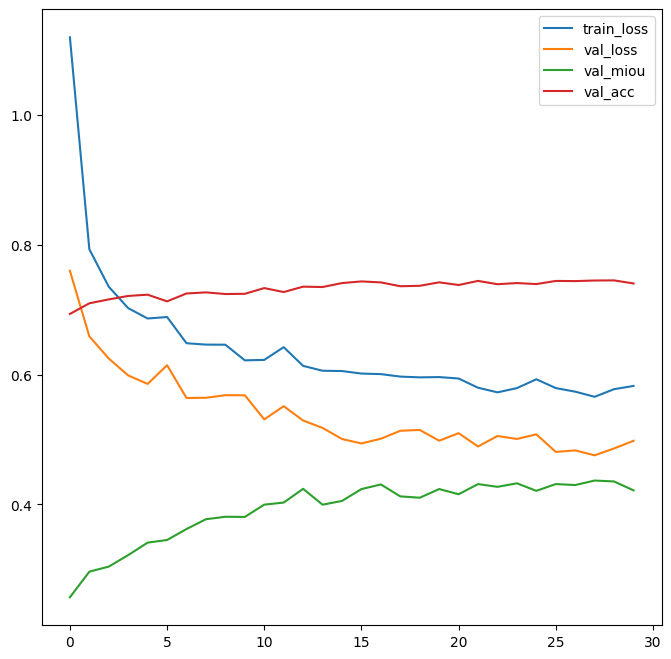

In [43]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 1, 1)
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.plot([t.cpu().item() if torch.is_tensor(t) else t for t in val_mious], label="val_miou")
plt.plot(val_accs, label="val_acc")
plt.legend()
plt.show()

### 可视化

In [44]:
CITYSCAPES_COLORS = [
    (128, 64, 128), (244, 35, 232), (70, 70, 70), (102, 102, 156),
    (190, 153, 153), (153, 153, 153), (250, 170, 30), (220, 220, 0),
    (107, 142, 35), (152, 251, 152), (70, 130, 180), (220, 20, 60),
    (255, 0, 0), (0, 0, 142), (0, 0, 70), (0, 60, 100),
    (0, 80, 100), (0, 0, 230), (119, 11, 32),
]


def colorize_mask(mask):
    """将 trainId 掩码 (H, W) 转换为 RGB，255 为忽略区域"""
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for cid, col in enumerate(CITYSCAPES_COLORS):
        color_mask[mask == cid] = col
    color_mask[mask == 255] = (0, 0, 0)
    return color_mask


mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img_tensor):
    """反归一化，用于可视化输入图像"""
    img = img_tensor.clone().cpu()
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

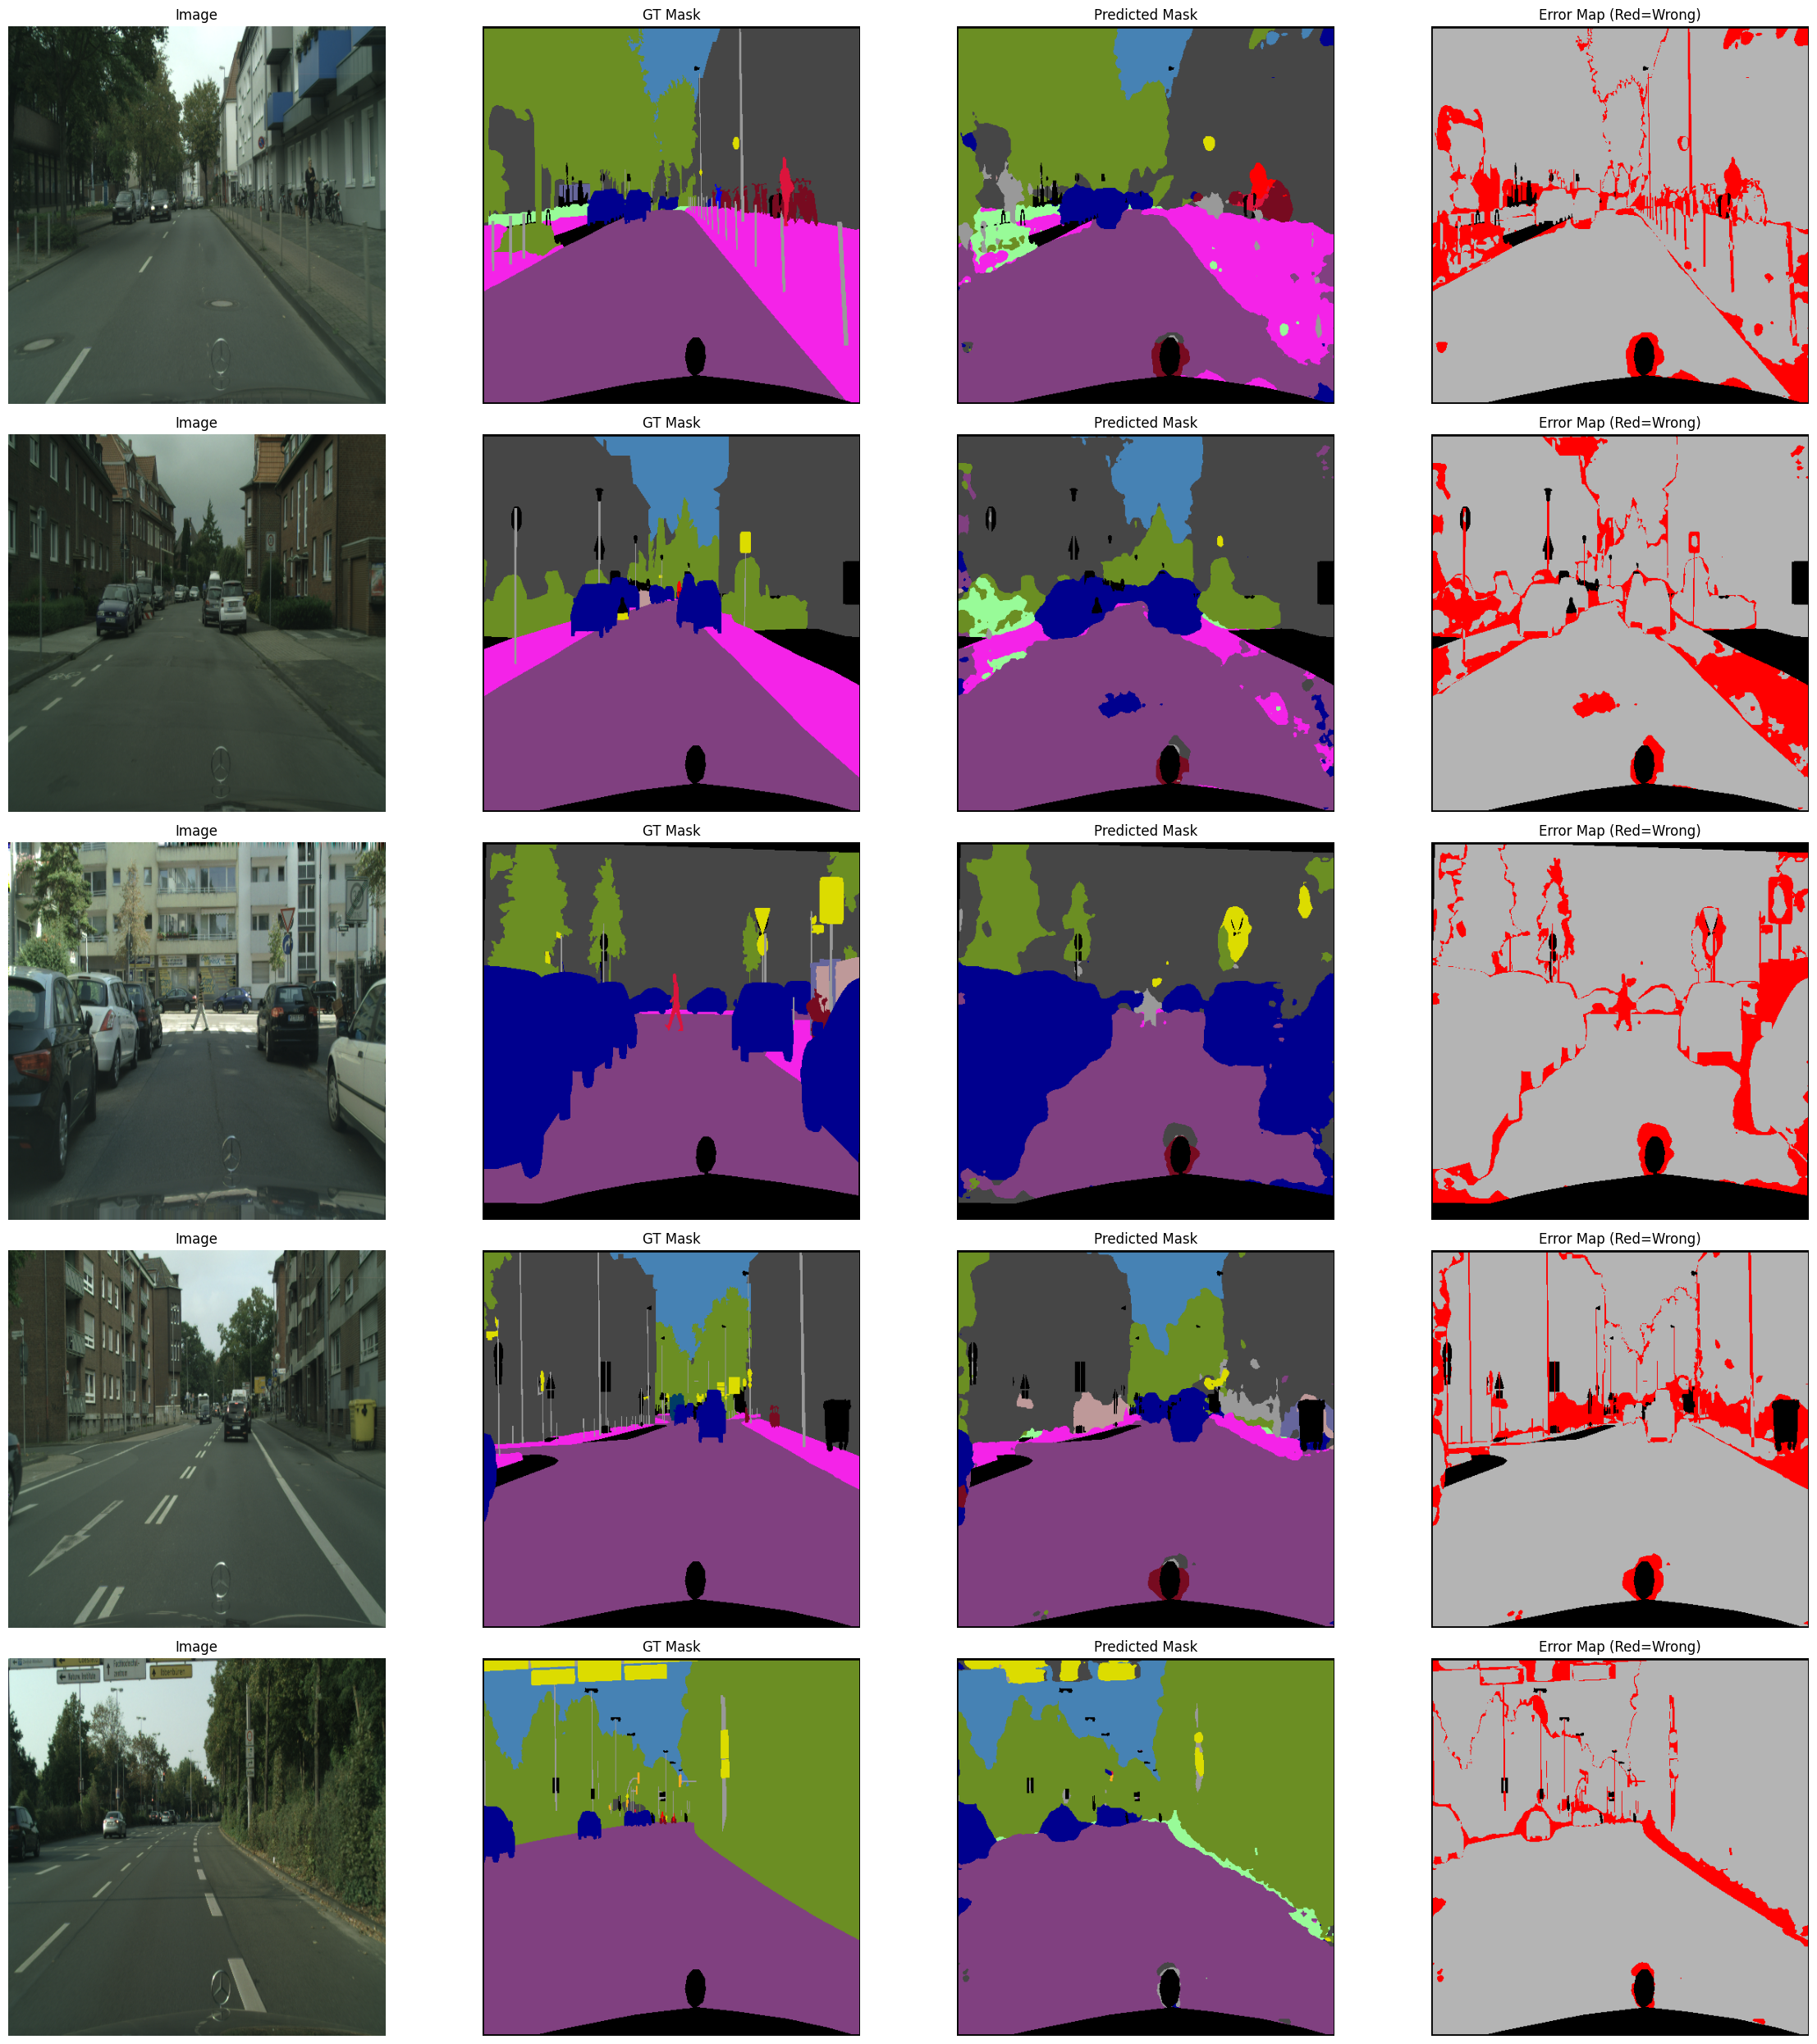

In [45]:
N = 5
fig, axes = plt.subplots(N, 4, figsize=(4 * 6, N * 5))
random_indices = random.sample(range(len(val_dataset)), N)

model.eval()
for row, idx in enumerate(random_indices):
    img, gt_mask = val_dataset[idx]
    img_np = denormalize(img)
    gt_np = gt_mask.cpu().numpy().astype(np.uint8)
    valid = gt_np != 255
    gt_color = colorize_mask(gt_np)

    img_input = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(img_input)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    pred_mask_vis = pred_mask.copy()
    pred_mask_vis[~valid] = 255
    pred_color = colorize_mask(pred_mask_vis)

    diff = np.zeros((*gt_np.shape, 3), dtype=np.uint8)
    correct = (pred_mask == gt_np) & valid
    incorrect = (pred_mask != gt_np) & valid
    diff[correct] = (180, 180, 180)
    diff[incorrect] = (255, 0, 0)
    diff[~valid] = (0, 0, 0)

    axes[row][0].imshow(img_np)
    axes[row][0].set_title("Image")
    axes[row][0].axis("off")
    axes[row][1].imshow(gt_color)
    axes[row][1].set_title("GT Mask")
    axes[row][1].axis("off")
    axes[row][2].imshow(pred_color)
    axes[row][2].set_title("Predicted Mask")
    axes[row][2].axis("off")
    axes[row][3].imshow(diff)
    axes[row][3].set_title("Error Map (Red=Wrong)")
    axes[row][3].axis("off")

plt.tight_layout()
plt.show()